# =========================
# Customer Churn Prediction using Machine Learning
# (Logistic Regression & Random Forest)
# =========================



Customer Churn Prediction using Machine Learning
(Logistic Regression & Random Forest)

In [1]:
# 1) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

plt.rcParams["figure.figsize"] = (10, 5)

# =========================
# 2) Load Data
# =========================

In [7]:
import os

print(os.listdir('/content'))

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [8]:
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# =========================
# 3) Data Overview
# =========================

In [9]:
display(df.info())
print("\nMissing values (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None


Missing values (top 20):


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# =========================
# 4) Cleaning + Target Setup
# =========================

In [10]:
# Convert target "Churn" from Yes/No to 1/0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Convert TotalCharges to numeric (some rows have blanks)
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop ID column if present (not predictive)
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("\nChurn rate:", round(df["Churn"].mean(), 3))



Churn rate: 0.265


# =========================
# 5) Quick EDA
# ========================

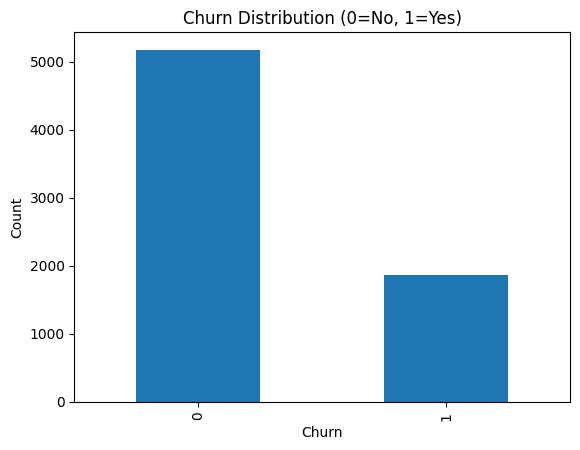

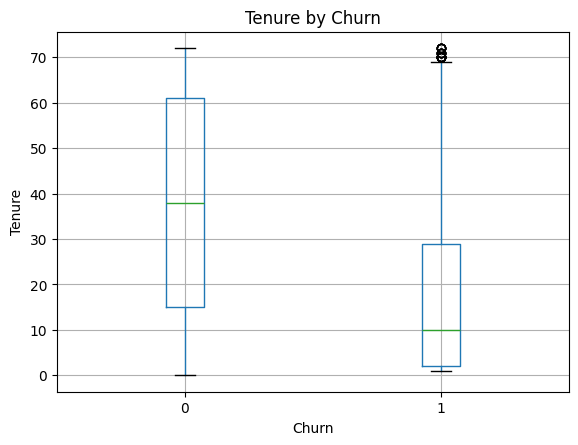

In [15]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution (0=No, 1=Yes)")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()
if "tenure" in df.columns:
    df.boxplot(column="tenure", by="Churn")
    plt.title("Tenure by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel("Tenure")
    plt.show()

# =========================
# 6) Train/Test Split
# =========================

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify numeric/categorical columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# =========================
# 7) Preprocessing Pipeline
# =========================

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


# =========================
# 8) Baseline Model: Logistic Regression
# =========================

In [23]:
# sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# =========================
# 9) Stronger Model: Random Forest
# =========================


=== Random Forest ===
ROC-AUC: 0.8217
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



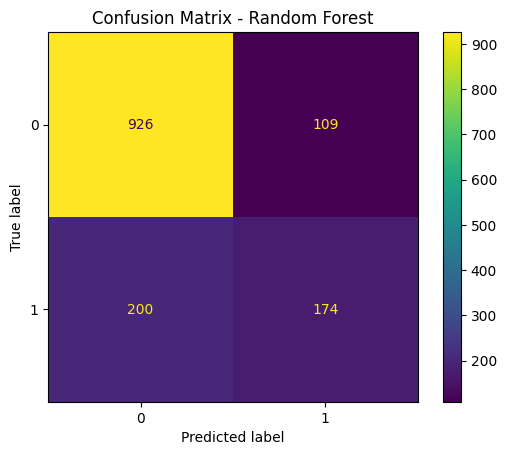

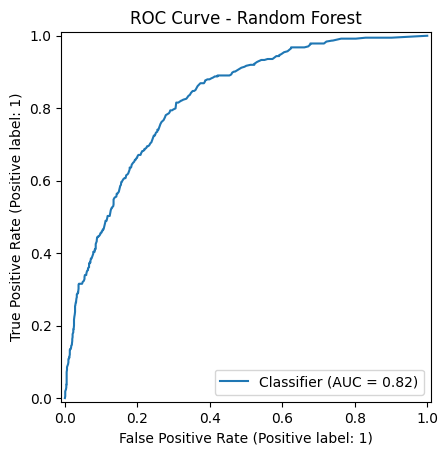

In [24]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)

print("\n=== Random Forest ===")
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve - Random Forest")
plt.show()


# =========================
# 10) Feature Importance (Random Forest)
# =========================


Top 20 Important Features:


,feature,importance
3,TotalCharges,0.142224
1,tenure,0.130183
2,MonthlyCharges,0.123131
36,Contract_Month-to-month,0.073013
18,OnlineSecurity_No,0.037625
38,Contract_Two year,0.035425
27,TechSupport_No,0.032842
43,PaymentMethod_Electronic check,0.028849
16,InternetService_Fiber optic,0.028671
21,OnlineBackup_No,0.016929


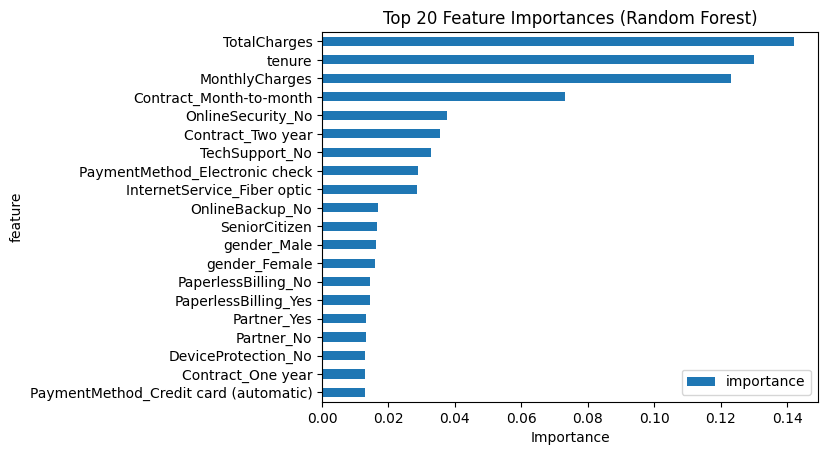

In [25]:
# Get OneHot feature names
ohe = rf_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

importances = rf_model.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": all_feature_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False).head(20)

print("\nTop 20 Important Features:")
display(fi)

fi.plot(kind="barh", x="feature", y="importance")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()



# =========================
# 11) Add evaluation metrics
# =========================


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.7814052519517388
[[927 108]
 [200 174]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409




# =========================
# 12 Add Add ROC curve
# =========================

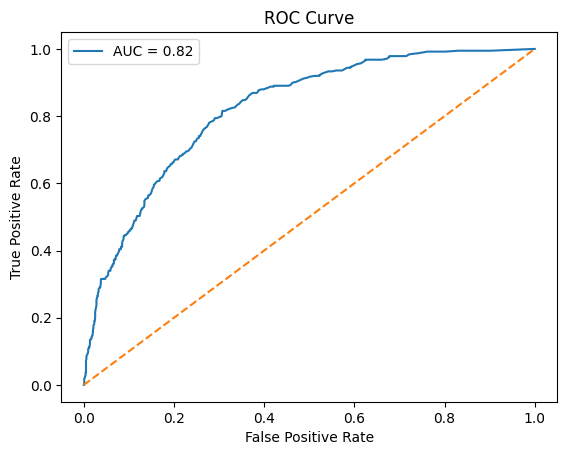

In [27]:
from sklearn.metrics import roc_curve, auc

probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# =========================
# 13 business interpretation
# =========================

## Business Insight

The model suggests the strongest churn drivers are:

• Contract type

• Monthly charges

• Tenure

Customers with short tenure and month-to-month contracts
have the highest probability of churn.

Recommendation:
Focus retention campaigns on these customers.